# Contextual Multi-Armed Bandit with BNN-Based Quantitative Model

This notebook demonstrates the usage of a **Bayesian Neural Network (BNN) based quantitative model** for continuous action parameters with the contextual multi-armed bandit (CMAB) implementation in `pybandits`.

The BNN quantitative model maps context features and a continuous action parameter (e.g., price, dosage, bid) to a reward distribution. A Bayesian Neural Network is used to model the relationship between context, the quantitative parameter, and the expected reward, providing uncertainty estimates that support exploration–exploitation. Unlike discrete-action CMABs, this approach lets you learn and optimize over continuous or fine-grained quantitative choices while conditioning on context.

**Key aspects:**
- **Context + quantity**: The model takes both contextual features and a scalar (or vector) quantitative parameter as input.
- **Uncertainty-aware**: The BNN yields a posterior over rewards, which the bandit can use for Thompson sampling or similar strategies.
- **Flexible fitting**: Supports variational inference (VI) or other Bayesian update methods for the BNN weights.

In [98]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pybandits.cmab import CmabBernoulli
from pybandits.quantitative_model import BaseQuantitativeBayesianNeuralNetwork

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Setup

First, we'll define actions with quantitative parameters. In this example, we'll use two actions, each with a one-dimensional quantitative parameter (e.g., price point or dosage level) ranging from 0 to 1. Unlike the SMAB model, here we also need to define contextual features.

In [99]:
# For reproducibility
np.random.seed(42)

# Define number of features for the context
n_features = 3
# Define number of segments for each action
n_max_segments = 16  # Maximum number of segments for each action

# Define cold start parameters for the base model
update_method = "VI"  # Variational Inference for Bayesian updates
update_kwargs = {"fit": {"n": 20000}, "optimizer_type": "adam", "learning_rate": 0.01}
dist_params_init = {"mu": 0, "sigma": 1, "nu": 5}

# Define actions with zooming models
actions = {
    "action_1": BaseQuantitativeBayesianNeuralNetwork.cold_start(
        dimension=1,
        n_features=n_features,
        hidden_dim_list=[10],
        update_method="VI",
        update_kwargs=update_kwargs,
        dist_params_init=dist_params_init,
    ),
    # "action_2": BaseQuantitativeBayesianNeuralNetwork.cold_start(
    #     dimension=1,
    #     n_features=n_features,
    #     hidden_dim_list=[5, 5],
    #     update_method="VI",
    #     update_kwargs=update_kwargs,
    #     dist_params_init=dist_params_init,
    # ),
}

In [100]:
actions["action_1"].bnn.update_kwargs

{'fit': {'method': 'advi', 'n': 20000},
 'optimizer_type': 'adam',
 'learning_rate': 0.01}

Now we can initialize the CmabBernoulli bandit with our zooming models:

In [101]:
# Initialize the bandit
cmab = CmabBernoulli(actions=actions, epsilon=1.0)

/mnt/VAST_SHARED/DS_SHARED/users/ronshi/git_projects/pybandits/pybandits/actions_manager.py:124: UserWarning: Only a single action was supplied. This MAB will be deterministic.
  warnings.warn("Only a single action was supplied. This MAB will be deterministic.")


In [102]:
cmab.actions["action_1"].bnn.update_kwargs

{'fit': {'method': 'advi', 'n': 20000},
 'optimizer_type': 'adam',
 'learning_rate': 0.01}

## Simulate Environment

Let's create a reward function that depends on both the action, its quantitative parameter, and the context. For illustration purposes, we'll define that:

- `action_1` performs better when the first context feature is high and when the quantitative parameter is around 0.25
- `action_2` performs better when the second context feature is high and when the quantitative parameter is around 0.75

The reward probability follows a bell curve for the quantitative parameter and is also influenced by the context features.

In [103]:
def reward_function(action, quantity, context):
    if action == "action_1":
        # Bell curve centered at 0.25 for the quantity
        # Influenced by first context feature
        quantity_component = np.exp(-((quantity - 0.25) ** 2) / 0.02)
        context_component = 0.1 + 0.9 * (context[0] / 2)  # First feature has influence
        prob = quantity_component * context_component
    else:  # action_2
        # Bell curve centered at 0.75 for the quantity
        # Influenced by second context feature
        quantity_component = np.exp(-((quantity - 0.75) ** 2) / 0.02)
        context_component = 0.5 + 0.5 * (context[1] / 2)  # Second feature has influence
        prob = quantity_component * context_component

    # Ensure probability is between 0 and 1
    prob = max(0, min(1, prob))

    return np.random.binomial(1, prob), prob

Let's visualize our reward functions to understand what the bandit needs to learn. We'll show the reward surfaces for different values of context:

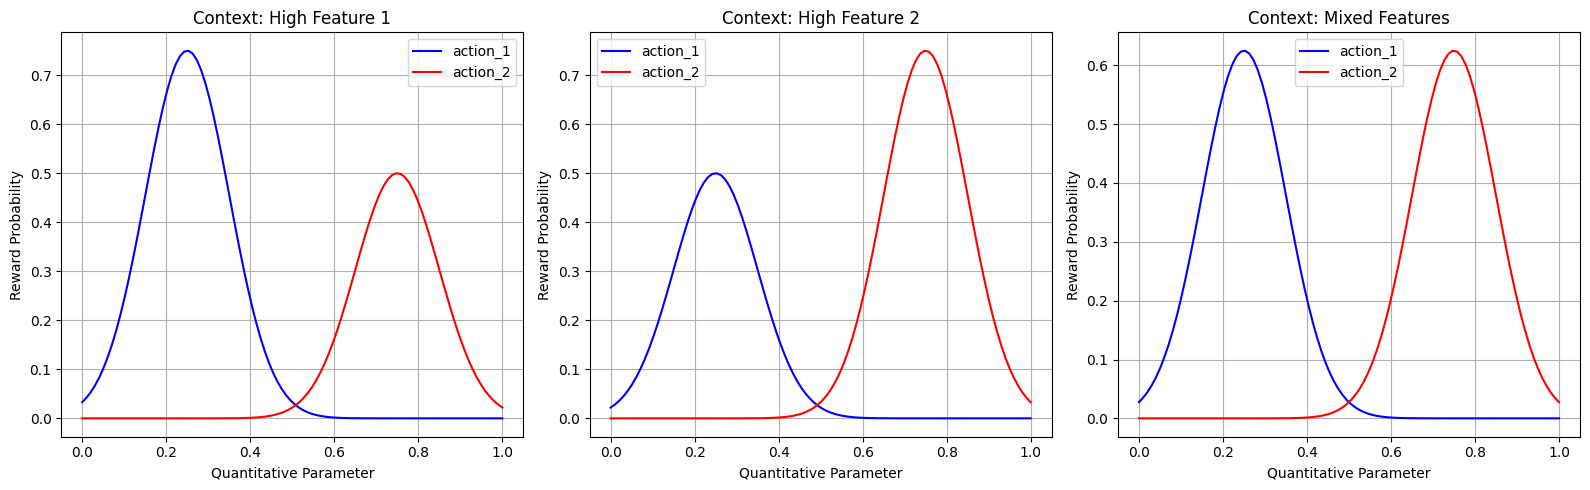

In [104]:
x = np.linspace(0, 1, 100)

# Plot for three different contexts
contexts = [
    np.array([1.0, 0.0, 0.0]),  # High first feature
    np.array([0.0, 1.0, 0.0]),  # High second feature
    np.array([0.5, 0.5, 0.0]),  # Mixed features
]

plt.figure(figsize=(16, 5))
for i, context in enumerate(contexts, 1):
    plt.subplot(1, 3, i)

    y1 = [np.exp(-((xi - 0.25) ** 2) / 0.02) * (0.5 + 0.5 * (context[0] / 2)) for xi in x]
    y2 = [np.exp(-((xi - 0.75) ** 2) / 0.02) * (0.5 + 0.5 * (context[1] / 2)) for xi in x]

    plt.plot(x, y1, "b-", label="action_1")
    plt.plot(x, y2, "r-", label="action_2")
    plt.xlabel("Quantitative Parameter")
    plt.ylabel("Reward Probability")

    if i == 1:
        title = "Context: High Feature 1"
    elif i == 2:
        title = "Context: High Feature 2"
    else:
        title = "Context: Mixed Features"

    plt.title(title)
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

## Generate Synthetic Context Data

Let's create synthetic context data for our experiment:

In [105]:
# Generate random context data
n_batches = 3
batch_size = 5000
n_rounds = n_batches * batch_size
context_data = np.random.uniform(0, 1, (n_rounds, n_features))

# Preview the context data
pd.DataFrame(context_data[:5], columns=[f"Feature {i + 1}" for i in range(n_features)])

,Feature 1,Feature 2,Feature 3
0,0.374540,0.950714,0.731994
1,0.598658,0.156019,0.155995
2,0.058084,0.866176,0.601115
3,0.708073,0.020584,0.969910
4,0.832443,0.212339,0.181825


## Bandit Training Loop

Now, let's train our bandit by simulating interactions for several rounds:

### BNN

In [107]:
for t in range(n_batches):
    # Get context for this round
    current_context = context_data[t * batch_size : (t + 1) * batch_size]

    # Predict best action
    pred_actions, probs, weighted_sums = cmab.predict(context=current_context)
    chosen_actions = [a[0] for a in pred_actions]
    chosen_quantities = [a[1][0] for a in pred_actions]

    # Observe reward
    rewards = [
        reward_function(chosen_action, chosen_quantity, _current_context)[0]
        for chosen_action, chosen_quantity, _current_context in zip(chosen_actions, chosen_quantities, current_context)
    ]

    # Update bandit
    cmab.update(actions=chosen_actions, rewards=rewards, context=current_context, quantities=chosen_quantities)

    # Print progress
    print(f"Completed {t} batches")

/home/ronshi/.conda/envs/pybandits4/lib/python3.10/site-packages/pymc/data.py:434: UserWarning: The `mutable` kwarg was not specified. Before v4.1.0 it defaulted to `pm.Data(mutable=True)`, which is equivalent to using `pm.MutableData()`. In v4.1.0 the default changed to `pm.Data(mutable=False)`, equivalent to `pm.ConstantData`. Use `pm.ConstantData`/`pm.MutableData` or pass `pm.Data(..., mutable=False/True)` to avoid this warning.
  warnings.warn(


Completed 0 batches


/home/ronshi/.conda/envs/pybandits4/lib/python3.10/site-packages/pymc/data.py:434: UserWarning: The `mutable` kwarg was not specified. Before v4.1.0 it defaulted to `pm.Data(mutable=True)`, which is equivalent to using `pm.MutableData()`. In v4.1.0 the default changed to `pm.Data(mutable=False)`, equivalent to `pm.ConstantData`. Use `pm.ConstantData`/`pm.MutableData` or pass `pm.Data(..., mutable=False/True)` to avoid this warning.
  warnings.warn(


Completed 1 batches


/home/ronshi/.conda/envs/pybandits4/lib/python3.10/site-packages/pymc/data.py:434: UserWarning: The `mutable` kwarg was not specified. Before v4.1.0 it defaulted to `pm.Data(mutable=True)`, which is equivalent to using `pm.MutableData()`. In v4.1.0 the default changed to `pm.Data(mutable=False)`, equivalent to `pm.ConstantData`. Use `pm.ConstantData`/`pm.MutableData` or pass `pm.Data(..., mutable=False/True)` to avoid this warning.
  warnings.warn(


Completed 2 batches


In [109]:

grid = np.mgrid[0:1:0.01, 0:1:0.01].astype(float)
grid_2d = grid.reshape(2, -1).T
grid_2d
grid_2d = np.append(grid_2d, np.zeros((grid_2d.shape[0], 2)), axis=1)
grid_2d

array([[0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.01, 0.  , 0.  ],
       [0.  , 0.02, 0.  , 0.  ],
       ...,
       [0.99, 0.97, 0.  , 0.  ],
       [0.99, 0.98, 0.  , 0.  ],
       [0.99, 0.99, 0.  , 0.  ]])

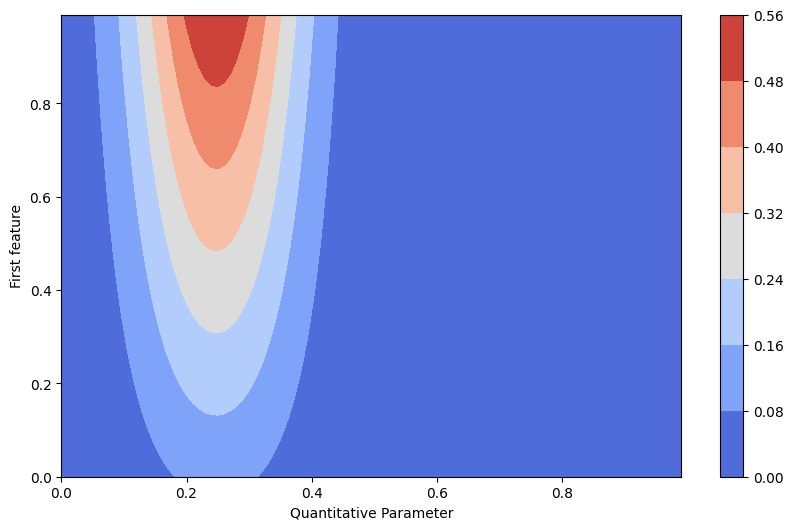

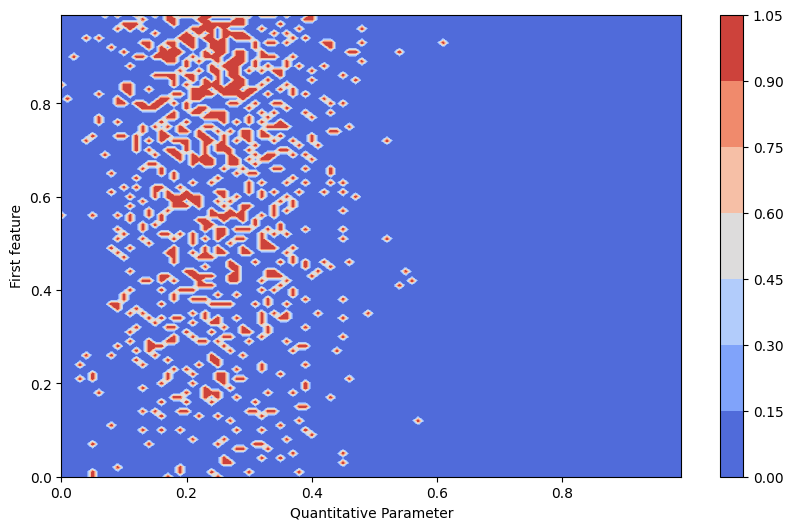

In [110]:
# real reward function for action 1
y_true  = np.zeros((100, 100))
reward_prob = np.zeros((100, 100))
for i, quantity in enumerate(np.linspace(0, 1, 100)):
    for j, first_feature in enumerate(np.linspace(0, 1, 100)):
        y_true[i,j], reward_prob[i, j] = reward_function(action="action_1", quantity=quantity, context=[first_feature, 0, 0])

cmap = plt.get_cmap("coolwarm")

fig, ax = plt.subplots(figsize=(10, 6))

# Create the contour plot
contour = ax.contourf(*grid, reward_prob.reshape(100, 100), cmap=cmap)
cbar = plt.colorbar(contour, ax=ax)
ax.set(ylabel="First feature", xlabel="Quantitative Parameter")
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
contour = ax.contourf(*grid, y_true.reshape(100, 100), cmap=cmap)
cbar = plt.colorbar(contour, ax=ax)
ax.set(ylabel="First feature", xlabel="Quantitative Parameter")
plt.show()




In [ ]:

batch_predictions = [
    cmab.actions["action_1"].bnn.sample_proba(grid_2d) for _ in range(500)
]  # predictions are list of tuples of probabilities and corresponding weighted sums
batch_proba = np.array(
    [[proba_and_weighted_sum[0] for proba_and_weighted_sum in predictions] for predictions in batch_predictions]
)

In [122]:
# Calculate AUC
from sklearn.metrics import accuracy_score, roc_auc_score
auc = roc_auc_score(y_true, batch_proba.mean(axis=0).reshape(100, 100))
print(f"AUC: {auc}")

AUC: 0.8594812361258042


[Text(0, 0.5, 'First feature'), Text(0.5, 0, 'Quantitative Parameter')]

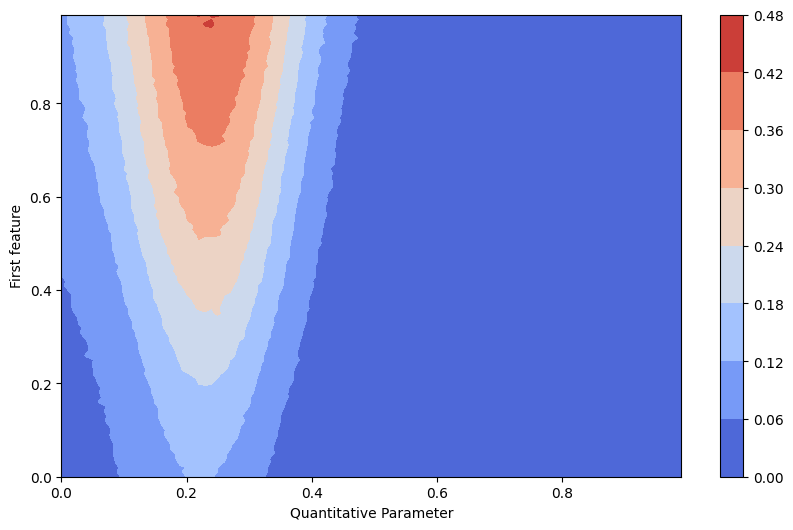

In [117]:
pred_proba_mean = batch_proba.mean(axis=0)

cmap = plt.get_cmap("coolwarm")

fig, ax = plt.subplots(figsize=(10, 6))

# Create the contour plot
contour = ax.contourf(*grid, pred_proba_mean.reshape(100, 100), cmap=cmap)
cbar = plt.colorbar(contour, ax=ax)
ax.set(ylabel="First feature", xlabel="Quantitative Parameter")

In [118]:
cmab.actions["action_1"].bnn

BayesianNeuralNetwork(n_successes=1260, n_failures=13742, model_params=BnnParams(bnn_layer_params=[BnnLayerParams(weight=StudentTArray(mu=[[-0.320702591752849, -2.285343881844425, -0.058810628089422765, 8.283449482808349, -5.24237710026159, 0.5407134083353056, 5.1772076110777725, -0.46031146670306194, 6.380528618654711, 0.013249766828716628], [-0.6158867425669271, -2.845621825268631, -0.10819770005406366, 0.32221769021824204, 0.86539218041892, 0.6580143935992435, 0.5182052975080427, -0.681731789896676, -0.48834403184447545, 0.10353984759557226], [-1.2906080415112346, 0.568666387560909, 0.03537074622579457, 0.12008566720544152, 0.2798452003755832, 1.1500626660006135, 0.1539033573275333, -1.444975987267093, -0.30753668901257275, -0.16792137366580695], [-1.0025869400118486, 0.40706602453434265, 0.0664003362610252, 0.18623084646460558, -0.4805983221684301, 1.9190879469081066, -0.6486700912516514, -0.7585077781362656, -0.3101284750758702, 0.056799813260570105]], sigma=[[0.9904437478176094, 

## Examining Segment Adaptation

Let's look at the adaptive segmentation for one of the actions to see how the model has split the quantitative space:

In [119]:
# # Extract the segmentation for one of the actions
# action1_segments = list(cmab.actions["action_1"].segmented_actions.keys())
# action2_segments = list(cmab.actions["action_2"].segmented_actions.keys())

# # Print the number of segments
# print(f"Number of segments for action_1: {len(action1_segments)}")
# print(f"Number of segments for action_2: {len(action2_segments)}")

# # Create a figure to visualize the segments
# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# # Plot action_1 segments
# ax1.set_title("action_1 Segments")
# for i, segment in enumerate(action1_segments):
#     ax1.plot([segment.mins[0], segment.maxs[0]], [i, i], linewidth=5)
# ax1.set_xlim(0, 1)
# ax1.set_xlabel("Quantitative Parameter")
# ax1.axvline(0.25, color="red", linestyle="--", label="Optimal Value")
# ax1.legend()

# # Plot action_2 segments
# ax2.set_title("action_2 Segments")
# for i, segment in enumerate(action2_segments):
#     ax2.plot([segment.mins[0], segment.maxs[0]], [i, i], linewidth=5)
# ax2.set_xlim(0, 1)
# ax2.set_xlabel("Quantitative Parameter")
# ax2.axvline(0.75, color="red", linestyle="--", label="Optimal Value")
# ax2.legend()

# plt.tight_layout()
# plt.show()

## Testing with Specific Contexts

Finally, let's test our trained bandit with specific contexts to see if it has learned the optimal policy:

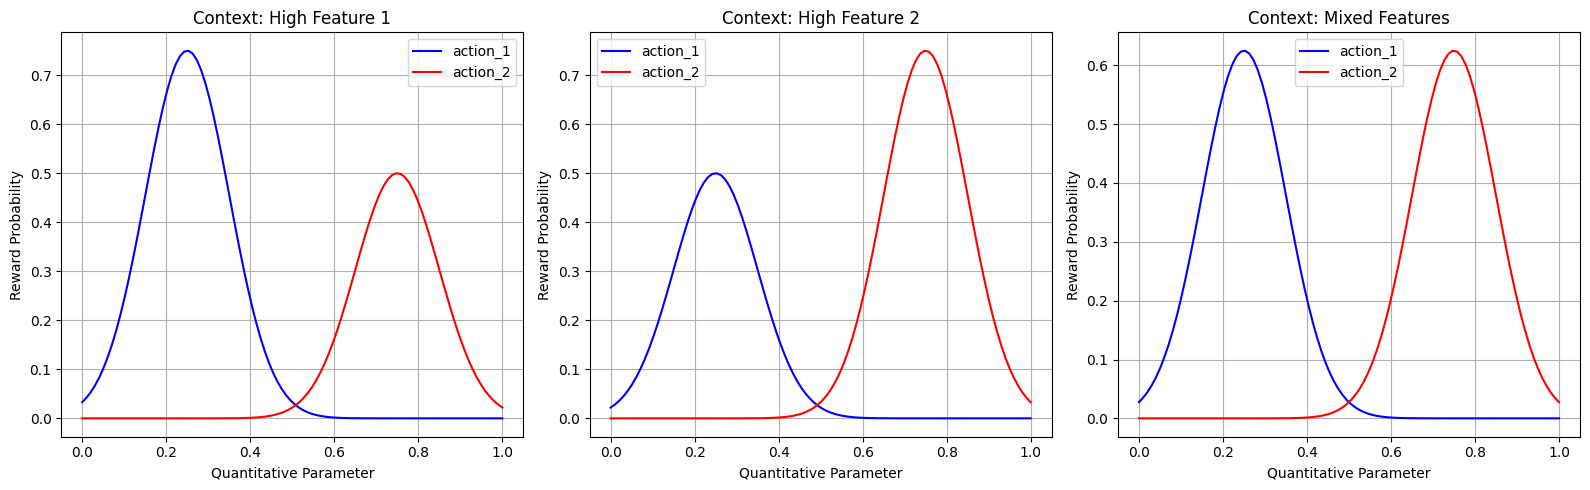

In [120]:
x = np.linspace(0, 1, 100)
n_samples = 100

# Plot for three different contexts
context = (np.array([1.0, 0.0, 0.0] * n_samples),)  # High first feature # Mixed features

plt.figure(figsize=(16, 5))
for i, context in enumerate(contexts, 1):
    plt.subplot(1, 3, i)

    y1 = [np.exp(-((xi - 0.25) ** 2) / 0.02) * (0.5 + 0.5 * (context[0] / 2)) for xi in x]
    y2 = [np.exp(-((xi - 0.75) ** 2) / 0.02) * (0.5 + 0.5 * (context[1] / 2)) for xi in x]

    plt.plot(x, y1, "b-", label="action_1")
    plt.plot(x, y2, "r-", label="action_2")
    plt.xlabel("Quantitative Parameter")
    plt.ylabel("Reward Probability")

    if i == 1:
        title = "Context: High Feature 1"
    elif i == 2:
        title = "Context: High Feature 2"
    else:
        title = "Context: Mixed Features"

    plt.title(title)
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

In [121]:
# Define test contexts
test_contexts = np.array(
    [
        [1.0, 0.0, 0.0],  # High feature 1, low feature 2
        [0.0, 1.0, 0.0],  # Low feature 1, high feature 2
        [1.0, 1.0, 0.0],  # High feature 1 and 2
        [0.0, 0.0, 0.0],  # Low feature 1 and 2
    ]
)

# Test predictions
results = []
for i, context in enumerate(test_contexts):
    context_reshaped = context.reshape(1, -1)
    pred_actions, probs, weighted_sums = cmab.predict(context=context_reshaped)
    chosen_action_quantity = pred_actions[0]
    chosen_action = chosen_action_quantity[0]
    chosen_quantities = chosen_action_quantity[1][0]
    chosen_action_probs = probs[0][chosen_action](chosen_quantities)

    # Sample optimal quantity for the chosen action
    # In a real application, you would have a method to test different quantities
    # Here we'll use our knowledge of the true optimal values
    if chosen_action == "action_1":
        optimal_quantity = 0.25
    else:
        optimal_quantity = 0.75

    # Expected reward probability
    expected_reward = reward_function(chosen_action, optimal_quantity, context)

    results.append(
        {
            "Context": context,
            "Chosen Action": chosen_action,
            "Chosen Qunatity": chosen_quantities,
            "Action Probabilities": chosen_action_probs,
            "Optimal Quantity": optimal_quantity,
            "Expected Reward": expected_reward,
        }
    )

# Display results
for i, result in enumerate(results):
    context_type = ""
    if i == 0:
        context_type = "High feature 1, low feature 2"
    elif i == 1:
        context_type = "Low feature 1, high feature 2"
    elif i == 2:
        context_type = "High feature 1 and 2"
    elif i == 3:
        context_type = "Low feature 1 and 2"

    print(f"\nTest {i + 1}: {context_type}")
    print(f"Context: {result['Context']}")
    print(f"Chosen Action: {result['Chosen Action']}")
    print(f"Chosen Quantity: {result['Chosen Qunatity']}")
    print(f"Action Probabilities: {result['Action Probabilities']}")
    print(f"Optimal Quantity: {result['Optimal Quantity']:.2f}")
    print(f"Expected Reward: {result['Expected Reward']}")


Test 1: High feature 1, low feature 2
Context: [1. 0. 0.]
Chosen Action: action_1
Chosen Quantity: 0.854576142736385
Action Probabilities: 0.004646159195726104
Optimal Quantity: 0.25
Expected Reward: (0, 0.55)

Test 2: Low feature 1, high feature 2
Context: [0. 1. 0.]
Chosen Action: action_1
Chosen Quantity: 0.5542455902870235
Action Probabilities: 0.003928325814544639
Optimal Quantity: 0.25
Expected Reward: (0, 0.1)

Test 3: High feature 1 and 2
Context: [1. 1. 0.]
Chosen Action: action_1
Chosen Quantity: 0.5891427177953703
Action Probabilities: 0.016154742807716452
Optimal Quantity: 0.25
Expected Reward: (1, 0.55)

Test 4: Low feature 1 and 2
Context: [0. 0. 0.]
Chosen Action: action_1
Chosen Quantity: 0.37312463344230284
Action Probabilities: 0.03626585244915811
Optimal Quantity: 0.25
Expected Reward: (0, 0.1)


## Conclusion

The CMAB Zooming model extends the concept of adaptive discretization to contextual bandits. This approach allows efficient exploration and exploitation of continuous action parameters while taking context into account. It adaptively refines the segmentation of the parameter space, concentrating more segments in high-reward regions for finer discretization.

This approach is particularly useful when:
1. Actions have continuous parameters that affect rewards
2. The reward function depends on both context and action parameters
3. The optimal parameter values may vary across different contexts
4. The action space needs to be adaptively discretized for efficient exploration

Real-world applications include:
- Personalized pricing: Find optimal prices (continuous parameter) based on customer features (context)
- Content recommendation: Optimize content parameters (e.g., length, complexity) based on user demographics
- Medical dosing: Determine optimal medication dosages based on patient characteristics
- Ad campaign optimization: Find best bid values based on ad placement and target audience